In [2]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
numbers = pd.read_csv(r"data/numbers.csv")
numbers

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [4]:
box_office=pd.read_csv(r"data/box_office_mojo.csv")
box_office

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [5]:
# Connect to the SQLite database
conn = sqlite3.connect(r'data/im.db')

cur=conn.cursor()

cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names


[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [6]:
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
table_names = cur.fetchall()
table_names

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [7]:
imdb=pd.read_sql(""" SELECT movie_ratings.movie_id,genres,runtime_minutes,start_year,primary_title,
             movie_ratings.numvotes , movie_ratings.averagerating
             FROM movie_basics
            JOIN movie_ratings
            ON movie_basics.movie_id = movie_ratings.movie_id""",conn)

imdb

,movie_id,genres,runtime_minutes,start_year,primary_title,numvotes,averagerating
0,tt0063540,"Action,Crime,Drama",175.0,2013,Sunghursh,77,7.0
1,tt0066787,"Biography,Drama",114.0,2019,One Day Before the Rainy Season,43,7.2
2,tt0069049,Drama,122.0,2018,The Other Side of the Wind,4517,6.9
3,tt0069204,"Comedy,Drama",NaN,2018,Sabse Bada Sukh,13,6.1
4,tt0100275,"Comedy,Drama,Fantasy",80.0,2017,The Wandering Soap Opera,119,6.5
...,...,...,...,...,...,...,...
73851,tt9913084,Documentary,75.0,2019,Diabolik sono io,6,6.2
73852,tt9914286,"Drama,Family",98.0,2019,Sokagin Çocuklari,136,8.7
73853,tt9914642,Documentary,NaN,2017,Albatross,8,8.5
73854,tt9914942,None,NaN,2019,La vida sense la Sara Amat,5,6.6


In [8]:
# Removing dollars sign from the numbers collection columns and converting them to numeric
numbers['production_budget'] = numbers['production_budget'].replace('[\$,]', '', regex=True).astype(float)
numbers['domestic_gross'] = numbers['domestic_gross'].replace('[\$,]', '', regex=True).astype(float)
numbers['worldwide_gross'] = numbers['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [9]:
# Split date column into day, month, year
numbers['release_date'] = pd.to_datetime(numbers['release_date'], errors='coerce')
numbers['release_day'] = numbers['release_date'].dt.day
numbers['release_month'] = numbers['release_date'].dt.month
numbers['release_year'] = numbers['release_date'].dt.year
months = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
numbers['months'] = numbers['release_month'].map(months)
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December


In [10]:
numbers['net'] = ((numbers['worldwide_gross']  - numbers['production_budget']))
numbers.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_day,release_month,release_year,months,net
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,18,12,2009,December,2.351345e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,20,5,2011,May,6.350639e+08
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,7,6,2019,June,-2.002376e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1,5,2015,May,1.072414e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,15,12,2017,December,9.997217e+08


In [11]:
#Loading cleaned data
c_numbers = pd.read_csv("cleaned_data/cleaned_numbers_data.csv")
c_box_office = pd.read_csv("cleaned_data/cleaned_box_office_data.csv")
c_imdb = pd.read_csv("cleaned_data/cleaned_imdb_data.csv")


In [12]:
# Use for loop to find the highest rated genres for each year
highest_rated_genres_per_year = {}
for year in c_imdb['start_year'].unique():
    yearly_data = c_imdb[c_imdb['start_year'] == year]
    highest_rated_genre = yearly_data.groupby('genres')['averagerating'].mean().idxmax()
    highest_rating = yearly_data.groupby('genres')['averagerating'].mean().max()
    highest_rated_genres_per_year[year] = (highest_rated_genre, round(highest_rating, 2))
    # print(f"In {year}, the highest rated genre was '{highest_rated_genre}' with an average rating of {highest_rating:.2f}.")
highest_rated_genres_per_year

{2013: ('Game-Show', 9.0),
 2019: ('Music', 8.35),
 2018: ('Music', 7.89),
 2017: ('Documentary', 7.38),
 2010: ('Documentary', 7.27),
 2011: ('Sport', 7.53),
 2012: ('Music', 7.64),
 2015: ('Documentary', 7.34),
 2016: ('Music', 7.65),
 2014: ('Music', 7.59)}

In [14]:
imdb_df = pd.read_csv("cleaned_data/cleaned_imdb_data.csv")
top_genres = (
    imdb_df.groupby('genres')
    .agg(avg_rating=('averagerating','mean'),
         views=('numvotes','sum'))
    .sort_values(['avg_rating','views'], ascending=False)
    .head(3)
)

top_genres

,avg_rating,views
genres,,
Game-Show,9.000000,7
Music,7.506771,42733
Documentary,7.316595,2974400


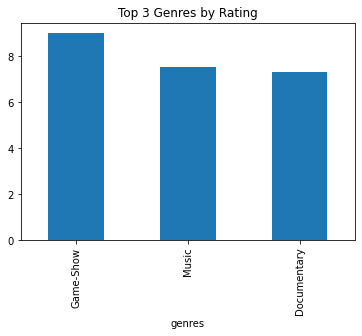

In [16]:
top_genres['avg_rating'].plot(kind='bar', title='Top 3 Genres by Rating')
plt.show()

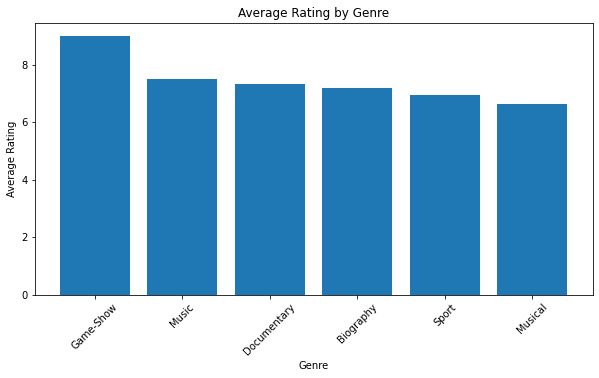

In [31]:
avg_rating_genre = (
    c_imdb.groupby("genres")["averagerating"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
)

plt.figure(figsize=(10,5))
plt.bar(avg_rating_genre.index, avg_rating_genre.values)
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [35]:
c_numbers['month'] = pd.to_datetime(c_numbers['release_date']).dt.month_name()

monthly_performance = (
    c_numbers.groupby('month')['worldwide_gross']
    .mean()
    .sort_values(ascending=False)
)

monthly_performance.head()

month
May         1.622680e+08
June        1.425230e+08
July        1.409636e+08
November    1.357416e+08
December    1.016932e+08
Name: worldwide_gross, dtype: float64

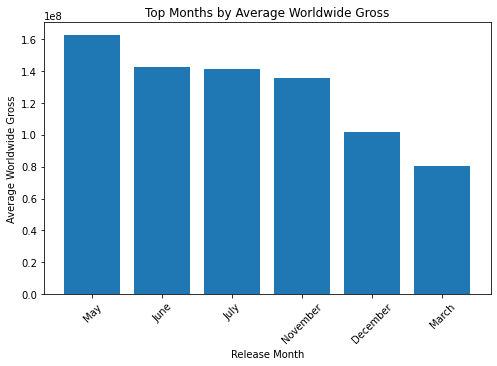

In [34]:
top_months = monthly_performance.head(6)

plt.figure(figsize=(8,5))
plt.bar(top_months.index, top_months.values)
plt.title("Top Months by Average Worldwide Gross")
plt.xlabel("Release Month")
plt.ylabel("Average Worldwide Gross")
plt.xticks(rotation=45)
plt.show()

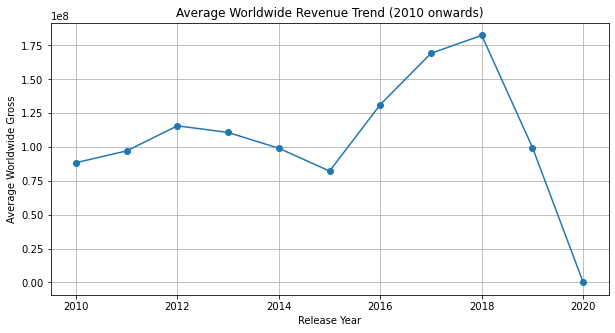

In [30]:
c_numbers_2010 = c_numbers[c_numbers['release_year'] >= 2010]
yearly_revenue = (
    c_numbers_2010.groupby('release_year')['worldwide_gross']
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(yearly_revenue.index, yearly_revenue.values, marker='o')
plt.title("Average Worldwide Revenue Trend (2010 onwards)")
plt.xlabel("Release Year")
plt.ylabel("Average Worldwide Gross")
plt.grid(True)
plt.show()

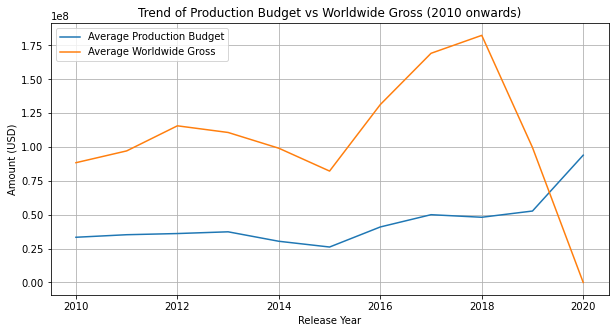

In [ ]:
c_numbers_2010 = c_numbers[c_numbers['release_year'] >= 2010]
budget_gross_trend = (
    c_numbers_2010.groupby('release_year')[['production_budget','worldwide_gross']]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(budget_gross_trend.index, budget_gross_trend['production_budget'],
         label='Average Production Budget')
plt.plot(budget_gross_trend.index, budget_gross_trend['worldwide_gross'],
         label='Average Worldwide Gross')

plt.title("Trend of Production Budget vs Worldwide Gross (2010 onwards)")
plt.xlabel("Release Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

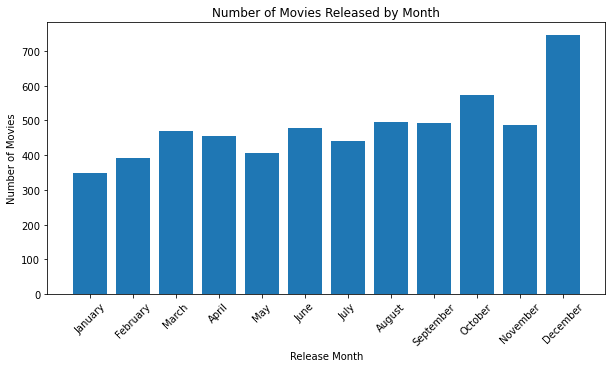

In [32]:
c_numbers['month'] = pd.to_datetime(c_numbers['release_date']).dt.month_name()
movies_per_month = (
    c_numbers['month']
    .value_counts()
)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

movies_per_month = movies_per_month.reindex(month_order)

plt.figure(figsize=(10,5))
plt.bar(movies_per_month.index, movies_per_month.values)
plt.title("Number of Movies Released by Month")
plt.xlabel("Release Month")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()